# CS-GY 6923 · Scaling Laws for SVG Language Models

**NYU Tandon School of Engineering — Spring 2026**

Trains decoder-only Transformers at five scales on SVG (Scalable Vector Graphics) code,
fits power-law scaling curves under standard parameterisation (SP) and Maximal Update
Parameterisation (µP), then generates and evaluates SVG samples.

**Parts**
1. Data collection and preprocessing
2. Transformer scaling study (SP)
3. µP scaling and power-law extrapolation
4. Best-model extended training and sample generation
5. Design-decision analysis

> **Runtime**: GPU (T4 or better).  All training cells are resumable: if a `_final.pt`
> checkpoint already exists in `/content/checkpoints` the cell loads it instead of re-training.

## 0 · Setup

In [1]:
# Install all required packages in one shot
!pip install -q datasets tokenizers lxml cairosvg mup scipy matplotlib seaborn tqdm Pillow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 11.1 MB/s eta 0:00:00


In [2]:
import os, re, json, math, time, random, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import t as tdist
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
print(f'Device : {DEVICE}')
print(f'AMP    : {USE_AMP}')
if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}')
    print(f'VRAM   : {props.total_memory / 1e9:.1f} GB')

Device : cuda
AMP    : True
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB


In [3]:
# ── Tokenisation ───────────────────────────────────────────────
VOCAB_SIZE  = 4096      # BPE vocabulary (actual size set after training)
SEQ_LEN     = 512       # context window (tokens)

# ── Optimisation ───────────────────────────────────────────────
BATCH_SIZE  = 32
WARMUP      = 200       # linear LR warmup steps
CLIP_GRAD   = 1.0       # gradient norm clipping
WD          = 0.1       # AdamW weight decay
ADAM_BETAS  = (0.9, 0.95)

# ── Directories ────────────────────────────────────────────────
DATA_DIR = Path('/content/data')
CKPT_DIR = Path('/content/checkpoints')
OUT_DIR  = Path('/content/results')

for _d in [DATA_DIR, CKPT_DIR, OUT_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print('DATA_DIR :', DATA_DIR)
print('CKPT_DIR :', CKPT_DIR)
print('OUT_DIR  :', OUT_DIR)

DATA_DIR : /content/data
CKPT_DIR : /content/checkpoints
OUT_DIR  : /content/results


In [4]:
# Checkpoints save to local Colab SSD (/content/checkpoints).
# All outputs are bundled into a zip and downloaded at the end of the notebook.
CKPT_DIR.mkdir(parents=True, exist_ok=True)
print('CKPT_DIR:', CKPT_DIR)

CKPT_DIR: /content/checkpoints


In [5]:
# ── HuggingFace Hub checkpoint persistence ─────────────────────────────────
# Checkpoints are pushed to a private HF repo after each model finishes.
# On reconnect, run this cell + the training cells — completed models are
# pulled back automatically and skipped.
#
# Get a token with write access at: https://huggingface.co/settings/tokens
HF_TOKEN   = ''                          # ← paste your HF token (do not commit)
HF_REPO_ID = 'ayush2k1/svg-scaling-ckpts'

HAS_HF = bool(HF_TOKEN.strip())

if HAS_HF:
    from huggingface_hub import HfApi, hf_hub_download, list_repo_files, create_repo
    _hf = HfApi(token=HF_TOKEN)
    try:
        create_repo(HF_REPO_ID, token=HF_TOKEN, repo_type='model',
                    private=True, exist_ok=True)
        print(f'HF Hub ready → {HF_REPO_ID}')
    except Exception as _e:
        print(f'HF Hub setup failed: {_e}')
        HAS_HF = False
else:
    print('HF_TOKEN not set — checkpoints will not survive disconnects.')


def hf_push(local_path: Path):
    """Upload one checkpoint file to HF Hub (silent if HF disabled)."""
    if not HAS_HF:
        return
    try:
        _hf.upload_file(
            path_or_fileobj=str(local_path),
            path_in_repo=local_path.name,
            repo_id=HF_REPO_ID,
            token=HF_TOKEN,
        )
        print(f'  ↑ HF pushed  {local_path.name}')
    except Exception as _e:
        print(f'  HF push failed ({local_path.name}): {_e}')


def hf_pull_all():
    """Download every *.pt in HF repo to CKPT_DIR (skips files already present)."""
    if not HAS_HF:
        return
    try:
        remote = [f for f in list_repo_files(HF_REPO_ID, token=HF_TOKEN)
                  if f.endswith('.pt')]
        if not remote:
            print('HF Hub: no checkpoints found.')
            return
        for fname in remote:
            dest = CKPT_DIR / fname
            if dest.exists():
                print(f'  ✓ already have  {fname}')
            else:
                hf_hub_download(repo_id=HF_REPO_ID, filename=fname,
                                local_dir=str(CKPT_DIR), token=HF_TOKEN)
                print(f'  ↓ HF pulled     {fname}')
    except Exception as _e:
        print(f'  HF pull failed: {_e}')

HF_TOKEN not set — checkpoints will not survive disconnects.


## 1 · Data Collection and Preprocessing

**Sources**
* `starvector/svg-icons-simple` — ~89 k simplified icons (primary)
* `starvector/svg-emoji-simple` — ~14.5 MB emoji (supplementary)
* `umuthopeyildirim/svgen-500k` — capped at 25 k for diversity

**Cleaning pipeline**: strip XML comments/metadata → normalise floats to 1 d.p. →
filter by length (50–8192 chars) → validate XML with `lxml`.

In [6]:
from datasets import load_dataset

# (HuggingFace dataset name, sample cap — None = take all)
# svg-icons-simple (~89k) + svg-emoji-simple together yield ~15–20 M tokens.
# svg-stack-simple (diverse, 3.87 GB) is added capped at 75 k to approach the 100 M minimum.
DATASETS: List[Tuple] = [
    ('starvector/svg-icons-simple', None),
    ('starvector/svg-emoji-simple', None),
    ('starvector/svg-stack-simple', 75_000),
    ('umuthopeyildirim/svgen-500k', 25_000),
]

# Column names to probe, ordered by likelihood
SVG_COLUMNS = ['Svg', 'svg', 'image', 'text', 'code', 'SVG', 'svg_code', 'svg_string']


def get_svg_col(ds) -> str:
    print('  columns:', ds.column_names)
    for col in SVG_COLUMNS:
        if col in ds.column_names:
            val = ds[0][col]
            if isinstance(val, str) and '<svg' in val.lower():
                print('  using column:', col)
                return col
    for col in ds.column_names:          # fallback: scan everything
        val = ds[0][col]
        if isinstance(val, str) and '<svg' in val.lower():
            print('  using column (fallback):', col)
            return col
    raise ValueError('No SVG column found in ' + str(ds.column_names))


raw_svgs: List[str] = []

for ds_name, cap in DATASETS:
    print(f'\nLoading {ds_name}')
    try:
        ds = load_dataset(ds_name, split='train')
        if cap is not None:
            ds = ds.select(range(min(cap, len(ds))))
            print(f'  capped at {len(ds):,}')
        col    = get_svg_col(ds)
        before = len(raw_svgs)
        for row in tqdm(ds, desc=ds_name):
            txt = row[col]
            if isinstance(txt, str) and txt.strip():
                raw_svgs.append(txt.strip())
        print(f'  added {len(raw_svgs) - before:,}  (running total {len(raw_svgs):,})')
    except Exception as exc:
        print(f'  skipped — {exc}')

print(f'\nTotal raw SVGs collected: {len(raw_svgs):,}')
assert raw_svgs, 'No SVGs loaded — check column detection output above.'


Loading starvector/svg-icons-simple


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/137M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.59M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/11.1M [00:00<?, ?B/s]

...

data/main.parquet:   0%|          | 0.00/211M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/216509 [00:00<?, ? examples/s]

  capped at 25,000
  columns: ['input', 'output', 'description', 'source', 'license']
  using column (fallback): output


umuthopeyildirim/svgen-500k:   0%|          | 0/25000 [00:00<?, ?it/s]

  added 24,982  (running total 184,530)

Total raw SVGs collected: 184,530


Cleaning:   0%|          | 0/184530 [00:00<?, ?it/s]

Input       : 184,530
Too short   : 0
Too long    : 1,807
Invalid XML : 3
Kept        : 182,720  (99.0%)


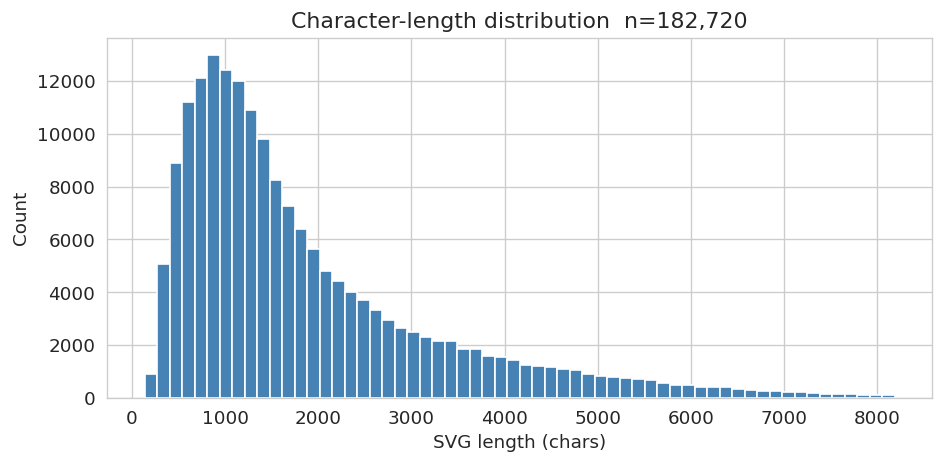

Min=135  Max=8191  Mean=1876  Median=1408


In [7]:
try:
    from lxml import etree
    HAS_LXML = True
except ImportError:
    HAS_LXML = False
    print('lxml not found — XML validation skipped.')

_RE_COMMENT = re.compile(r'<!--.*?-->', re.DOTALL)
_RE_META    = re.compile(r'<(metadata|desc|title)[^>]*>.*?</\1>', re.DOTALL | re.IGNORECASE)
_RE_WS      = re.compile(r'\s+')
_RE_FLOAT   = re.compile(r'(-?\d+\.\d{2,})')

MAX_CHARS = 8192
MIN_CHARS = 50


def _round_coords(text: str, dec: int = 1) -> str:
    return _RE_FLOAT.sub(lambda m: f'{float(m.group()):.{dec}f}', text)


n_short = n_long = n_xml_err = 0
clean_svgs: List[str] = []

for raw in tqdm(raw_svgs, desc='Cleaning'):
    s = raw.strip()
    s = re.sub(r'<\?xml[^?]*\?>', '', s)
    s = re.sub(r'<!DOCTYPE[^>]*>', '', s)
    s = _RE_COMMENT.sub('', s)
    s = _RE_META.sub('', s)
    s = _RE_WS.sub(' ', s).strip()
    s = _round_coords(s)

    if len(s) < MIN_CHARS:  n_short   += 1; continue
    if len(s) > MAX_CHARS:  n_long    += 1; continue
    if HAS_LXML:
        try:    etree.fromstring(s.encode())
        except: n_xml_err += 1; continue

    clean_svgs.append(s)

print(f'Input       : {len(raw_svgs):,}')
print(f'Too short   : {n_short:,}')
print(f'Too long    : {n_long:,}')
print(f'Invalid XML : {n_xml_err:,}')
print(f'Kept        : {len(clean_svgs):,}  ({100*len(clean_svgs)/max(1,len(raw_svgs)):.1f}%)')

if not clean_svgs:
    raise RuntimeError(
        f'All SVGs filtered — short={n_short}, long={n_long}, xml={n_xml_err}.'
    )

# Character-length histogram
char_lens = [len(s) for s in clean_svgs]
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(char_lens, bins=60, color='steelblue', edgecolor='white')
ax.set(xlabel='SVG length (chars)', ylabel='Count',
       title=f'Character-length distribution  n={len(clean_svgs):,}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'length_dist.png', dpi=120)
plt.show()
print(f'Min={min(char_lens)}  Max={max(char_lens)}  '
      f'Mean={np.mean(char_lens):.0f}  Median={np.median(char_lens):.0f}')

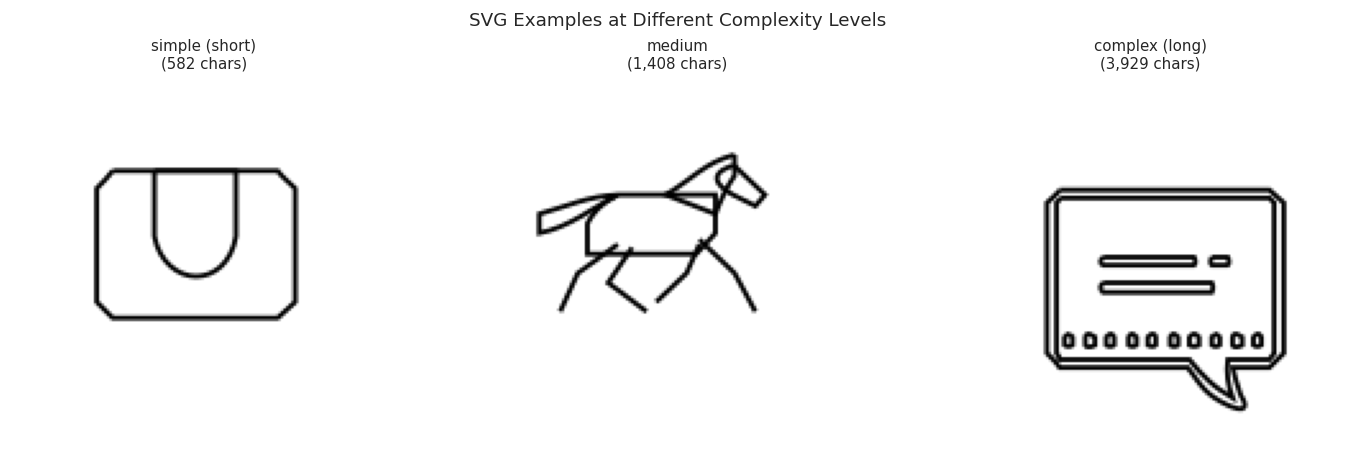


--- simple (short) ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M6.3 5.8 L11.5 5

--- medium ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M15.6 4.8 L15.6 

--- complex (long) ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M6.3 7.0 L12.9 7


In [8]:
# Display rendered SVG examples at low / medium / high complexity (by character length)
from IPython.display import display, Image as IPImage
import base64

def render_svg_to_png(svg_text: str, size: int = 150) -> bytes:
    try:
        import cairosvg
        return cairosvg.svg2png(bytestring=svg_text.encode(), output_width=size, output_height=size)
    except Exception:
        return None

sorted_svgs = sorted(clean_svgs, key=len)
n           = len(sorted_svgs)
examples    = {
    'simple (short)'  : sorted_svgs[n // 10],
    'medium'          : sorted_svgs[n // 2],
    'complex (long)'  : sorted_svgs[min(n - 1, int(n * 0.9))],
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (label, svg) in zip(axes, examples.items()):
    png = render_svg_to_png(svg)
    if png:
        from PIL import Image as PILImage
        import io
        img = PILImage.open(io.BytesIO(png))
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, 'render\nunavailable', ha='center', va='center',
                transform=ax.transAxes, fontsize=9, color='grey')
    ax.set_title(f'{label}\n({len(svg):,} chars)', fontsize=9)
    ax.axis('off')

plt.suptitle('SVG Examples at Different Complexity Levels', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'svg_examples.png', dpi=120, bbox_inches='tight')
plt.show()

for label, svg in examples.items():
    print(f'\n--- {label} ---')
    print(svg[:200])

In [9]:
# 98 / 1 / 1 split by document (not by token position) to prevent leakage
assert clean_svgs, 'Run the cleaning cell first.'

random.seed(42)
shuffled = clean_svgs.copy()
random.shuffle(shuffled)

n      = len(shuffled)
n_val  = max(1, int(n * 0.01))
n_test = max(1, int(n * 0.01))

split_data = {
    'train': shuffled[: n - n_val - n_test],
    'val'  : shuffled[n - n_val - n_test : n - n_test],
    'test' : shuffled[n - n_test :],
}

for name, subset in split_data.items():
    assert subset, f'{name} split is empty'
    path = DATA_DIR / f'{name}.txt'
    path.write_text('\n'.join(subset), encoding='utf-8')
    print(f'{name:>5}: {len(subset):>7,} SVGs  {path.stat().st_size / 1e6:.1f} MB')

train: 179,066 SVGs  336.1 MB
  val:   1,827 SVGs  3.5 MB
 test:   1,827 SVGs  3.4 MB


In [10]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as BLDecoder

TOKENIZER_PATH = str(DATA_DIR / 'tokenizer.json')
SPECIAL_TOKENS = ['<pad>', '<unk>', '<bos>', '<eos>']

tok = Tokenizer(BPE(unk_token='<unk>'))
tok.pre_tokenizer = ByteLevel(add_prefix_space=False)
tok.decoder       = BLDecoder()

trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=SPECIAL_TOKENS,
    min_frequency=2,
    show_progress=True,
)
print(f'Training BPE tokenizer (target vocab={VOCAB_SIZE}) …')
tok.train(files=[str(DATA_DIR / 'train.txt')], trainer=trainer)
tok.save(TOKENIZER_PATH)

VOCAB_SIZE = tok.get_vocab_size()   # actual post-training vocab size
BOS_ID     = tok.token_to_id('<bos>')
EOS_ID     = tok.token_to_id('<eos>')
print(f'Vocab size : {VOCAB_SIZE}  |  BOS={BOS_ID}  EOS={EOS_ID}')

Training BPE tokenizer (target vocab=4096) …
Vocab size : 4096  |  BOS=2  EOS=3


In [11]:
def _pack_split(split: str, chunk: int = 5000) -> int:
    """Encode split.txt → split.bin (uint16 array of token IDs)."""
    txt_path = DATA_DIR / f'{split}.txt'
    bin_path = DATA_DIR / f'{split}.bin'
    if not txt_path.exists():
        raise FileNotFoundError(f'{txt_path} missing — run split cell first.')

    docs = [s for s in txt_path.read_text('utf-8').split('\n') if s.strip()]
    if not docs:
        raise ValueError(f'{txt_path} is empty.')

    token_ids: List[int] = []
    for i in range(0, len(docs), chunk):
        for enc in tok.encode_batch(docs[i : i + chunk]):
            token_ids += [BOS_ID] + enc.ids + [EOS_ID]

    np.array(token_ids, dtype=np.uint16).tofile(str(bin_path))
    print(f'{split:>5}: {len(docs):>7,} SVGs  {len(token_ids):>12,} tokens')
    return len(token_ids)


token_counts = {}
for split in ('train', 'val', 'test'):
    token_counts[split] = _pack_split(split)

total_tokens = sum(token_counts.values())
print(f'\nTotal tokens : {total_tokens:,}')
if token_counts['train'] < 100_000_000:
    print('Warning: train set < 100 M tokens — consider adding more datasets.')

train: 179,066 SVGs   180,960,047 tokens
  val:   1,827 SVGs     1,862,185 tokens
 test:   1,827 SVGs     1,836,595 tokens

Total tokens : 184,658,827


Tokenising sample:   0%|          | 0/5000 [00:00<?, ?it/s]

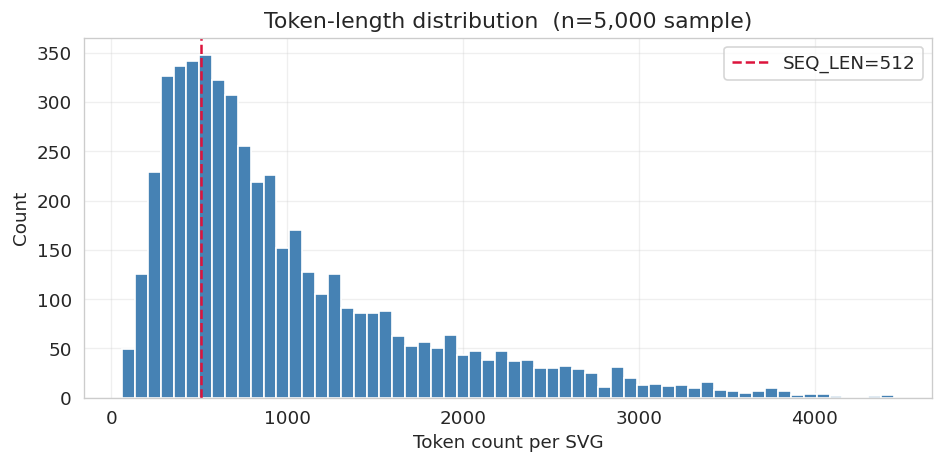

Median tokens : 750
Mean tokens   : 1000
Within SEQ_LEN: 29.4%


In [12]:
# Token-length distribution (sample of training SVGs)
sample_svgs = random.sample(clean_svgs, min(5000, len(clean_svgs)))
token_lens  = [len(tok.encode(s).ids) for s in tqdm(sample_svgs, desc='Tokenising sample')]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(token_lens, bins=60, color='steelblue', edgecolor='white')
ax.axvline(SEQ_LEN, color='crimson', ls='--', lw=1.5, label=f'SEQ_LEN={SEQ_LEN}')
ax.set(xlabel='Token count per SVG', ylabel='Count',
       title=f'Token-length distribution  (n={len(sample_svgs):,} sample)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'token_length_dist.png', dpi=120)
plt.show()

pct_within = sum(l <= SEQ_LEN for l in token_lens) / len(token_lens)
print(f'Median tokens : {int(np.median(token_lens))}')
print(f'Mean tokens   : {np.mean(token_lens):.0f}')
print(f'Within SEQ_LEN: {pct_within:.1%}')

## 2 · Model Architecture

Decoder-only transformer with pre-LayerNorm and causal masking, following the
nanoGPT architecture (Karpathy, 2022).  Two parameterisation modes are supported:

* **SP** (standard) — attention scale `1/√d`, weight-tied embedding and head,
  standard AdamW.
* **µP** — attention scale `1/d`, `MuReadout` output head, `MuAdamW` with
  per-layer LR multipliers determined by base-shape registration.

In [13]:
@dataclass
class ArchConfig:
    vocab_size : int   = 4096
    block_size : int   = 512
    d_model    : int   = 128
    n_layers   : int   = 4
    n_heads    : int   = 4
    d_ff       : int   = 512
    dropout    : float = 0.0
    bias       : bool  = False


class CausalAttention(nn.Module):
    def __init__(self, cfg: ArchConfig, mup_attn: bool = False):
        super().__init__()
        assert cfg.d_model % cfg.n_heads == 0
        self.n_heads   = cfg.n_heads
        self.d_head    = cfg.d_model // cfg.n_heads
        self.dropout   = cfg.dropout
        self.mup_attn  = mup_attn
        self.qkv       = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=cfg.bias)
        self.out_proj  = nn.Linear(cfg.d_model, cfg.d_model,     bias=cfg.bias)
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.resid_drop = nn.Dropout(cfg.dropout)
        self.flash = hasattr(F, 'scaled_dot_product_attention')

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        if self.mup_attn:
            scale = 1.0 / self.d_head          # µP: 1/d instead of 1/√d
            att = (q @ k.transpose(-2, -1)) * scale
            mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
            att = att.masked_fill(mask == 0, float('-inf'))
            att = self.attn_drop(F.softmax(att, dim=-1))
            y = att @ v
        elif self.flash:
            y = F.scaled_dot_product_attention(
                q, k, v,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True,
            )
        else:
            scale = 1.0 / math.sqrt(self.d_head)
            att = (q @ k.transpose(-2, -1)) * scale
            mask = torch.tril(torch.ones(T, T, device=x.device)).view(1, 1, T, T)
            att = att.masked_fill(mask == 0, float('-inf'))
            att = self.attn_drop(F.softmax(att, dim=-1))
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(y))


class FeedForward(nn.Module):
    def __init__(self, cfg: ArchConfig):
        super().__init__()
        self.fc1 = nn.Linear(cfg.d_model, cfg.d_ff, bias=cfg.bias)
        self.fc2 = nn.Linear(cfg.d_ff, cfg.d_model, bias=cfg.bias)
        self.dp  = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.dp(self.fc2(F.gelu(self.fc1(x))))


class TransformerBlock(nn.Module):
    def __init__(self, cfg: ArchConfig, mup_attn: bool = False):
        super().__init__()
        self.norm1 = nn.LayerNorm(cfg.d_model, bias=cfg.bias)
        self.attn  = CausalAttention(cfg, mup_attn=mup_attn)
        self.norm2 = nn.LayerNorm(cfg.d_model, bias=cfg.bias)
        self.ff    = FeedForward(cfg)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class SVGDecoder(nn.Module):
    def __init__(self, cfg: ArchConfig, mup_attn: bool = False):
        super().__init__()
        self.cfg      = cfg
        self.tok_emb  = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.pos_emb  = nn.Embedding(cfg.block_size, cfg.d_model)
        self.emb_drop = nn.Dropout(cfg.dropout)
        self.layers   = nn.ModuleList(
            [TransformerBlock(cfg, mup_attn) for _ in range(cfg.n_layers)]
        )
        self.ln_out   = nn.LayerNorm(cfg.d_model, bias=cfg.bias)

        if mup_attn:
            from mup import MuReadout
            self.head = MuReadout(cfg.d_model, cfg.vocab_size, bias=False)
        else:
            self.head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
            self.tok_emb.weight = self.head.weight   # weight tying (SP only)

        self.apply(self._init_weights)
        for n, p in self.named_parameters():
            if n.endswith('out_proj.weight') or n.endswith('fc2.weight'):
                nn.init.normal_(p, 0.0, 0.02 / math.sqrt(2 * cfg.n_layers))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.02)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos    = torch.arange(T, device=idx.device)
        x      = self.emb_drop(self.tok_emb(idx) + self.pos_emb(pos))
        for layer in self.layers:
            x = layer(x)
        x      = self.ln_out(x)
        logits = self.head(x if targets is not None else x[:, [-1], :])
        loss   = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1
            )
        return logits, loss

    def param_count(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def make_optimizer(self, lr: float, use_mup: bool = False):
        decay, no_decay = [], []
        for n, p in self.named_parameters():
            if p.requires_grad:
                (decay if p.dim() >= 2 else no_decay).append(p)
        groups = [{'params': decay,    'weight_decay': WD},
                  {'params': no_decay, 'weight_decay': 0.0}]
        if use_mup:
            from mup import MuAdamW
            return MuAdamW(groups, lr=lr, betas=ADAM_BETAS)
        return torch.optim.AdamW(
            groups, lr=lr, betas=ADAM_BETAS,
            fused=(DEVICE.type == 'cuda'),
        )

    @torch.no_grad()
    def sample_tokens(self, idx, max_new: int = 256, temperature: float = 1.0,
                      top_k: int = 50, top_p: Optional[float] = None,
                      eos_id: Optional[int] = None):
        for _ in range(max_new):
            ctx    = idx[:, -self.cfg.block_size:]
            logits, _ = self(ctx)
            logits = logits[:, -1, :] / temperature
            if top_k:
                kth, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < kth[:, [-1]]] = float('-inf')
            if top_p is not None:
                sl, si = torch.sort(logits, descending=True)
                cp = F.softmax(sl, dim=-1).cumsum(dim=-1)
                sl[cp - F.softmax(sl, dim=-1) > top_p] = float('-inf')
                logits.scatter_(1, si, sl)
            next_tok = torch.multinomial(F.softmax(logits, dim=-1), 1)
            idx = torch.cat([idx, next_tok], dim=1)
            if eos_id is not None and (next_tok == eos_id).all():
                break
        return idx


# Architecture configurations from the project specification
SIZE_CONFIGS = {
    'tiny'  : dict(d_model=128, n_layers=4,  n_heads=4,  d_ff=512),
    'small' : dict(d_model=192, n_layers=6,  n_heads=6,  d_ff=768),
    'medium': dict(d_model=384, n_layers=6,  n_heads=6,  d_ff=1536),
    'large' : dict(d_model=512, n_layers=10, n_heads=8,  d_ff=2048),
    'xl'    : dict(d_model=768, n_layers=12, n_heads=12, d_ff=3072),
}

print(f'  {"Size":<8} {"~Params":>12}   d_model  n_layers  n_heads   d_ff')
print('  ' + '-' * 62)
for sz, kw in SIZE_CONFIGS.items():
    m = SVGDecoder(ArchConfig(vocab_size=VOCAB_SIZE, block_size=SEQ_LEN, **kw))
    print(f'  {sz:<8} {m.param_count():>12,}   '
          f'{kw["d_model"]:>7}  {kw["n_layers"]:>8}  '
          f'{kw["n_heads"]:>7}  {kw["d_ff"]:>5}')

  Size          ~Params   d_model  n_layers  n_heads   d_ff
  --------------------------------------------------------------
  tiny        1,377,408       128         4        4    512
  small       3,541,440       192         6        6    768
  medium     12,391,296       384         6        6   1536
  large      33,827,328       512        10        8   2048
  xl         88,492,800       768        12       12   3072


## 3 · Dataset and Training Utilities

In [14]:
class PackedSVGDataset(Dataset):
    """Memory-mapped uint16 binary file of packed token sequences."""
    def __init__(self, bin_path: str, block_size: int):
        self.data  = np.memmap(bin_path, dtype=np.uint16, mode='r')
        self.block = block_size
        self.n     = max(0, (len(self.data) - 1) // block_size)

    def __len__(self): return self.n

    def __getitem__(self, i):
        s     = i * self.block
        chunk = self.data[s : s + self.block + 1].astype(np.int64)
        return torch.from_numpy(chunk[:-1]), torch.from_numpy(chunk[1:])


def get_loaders(block_size: int = SEQ_LEN, batch_size: int = BATCH_SIZE):
    kw = dict(pin_memory=True, num_workers=2)
    tr = PackedSVGDataset(str(DATA_DIR / 'train.bin'), block_size)
    va = PackedSVGDataset(str(DATA_DIR / 'val.bin'),   block_size)
    return (DataLoader(tr, batch_size=batch_size, shuffle=True,  drop_last=True,  **kw),
            DataLoader(va, batch_size=batch_size, shuffle=False, drop_last=False, **kw))


def cosine_schedule(step: int, max_lr: float, warmup: int, total: int,
                    min_ratio: float = 0.1) -> float:
    min_lr = max_lr * min_ratio
    if step < warmup:  return max_lr * step / max(1, warmup)
    if step >= total:  return min_lr
    t = (step - warmup) / max(1, total - warmup)
    return min_lr + 0.5 * (max_lr - min_lr) * (1.0 + math.cos(math.pi * t))


@torch.no_grad()
def estimate_val_loss(model: SVGDecoder, loader, n_iters: int = 50) -> float:
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if i >= n_iters: break
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_AMP):
            _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return float(np.mean(losses))


def checkpoint_save(path: Path, model: SVGDecoder, opt, step: int, stats: dict):
    torch.save({'step': step, 'model': model.state_dict(),
                'opt': opt.state_dict(), 'cfg': model.cfg, 'stats': stats}, path)


def checkpoint_load(path: Path, model: SVGDecoder, opt) -> Tuple[int, dict]:
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model'])
    opt.load_state_dict(ckpt['opt'])
    return ckpt['step'], ckpt['stats']


def fit_model(
    model: SVGDecoder,
    lr: float,
    max_steps: Optional[int] = None,
    run_name: str = 'run',
    use_mup: bool = False,
    log_every: int = 200,
    eval_every: int = 500,
    save_every: int = 500,
) -> dict:
    """Train for one epoch (or max_steps steps).  Fully resumable."""
    train_loader, val_loader = get_loaders()
    if max_steps is None:
        max_steps = len(train_loader)

    opt    = model.make_optimizer(lr, use_mup=use_mup)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    stats = {
        'run_name'     : run_name,
        'n_params'     : model.param_count(),
        'train_curve'  : [],   # list of (step, loss)
        'val_curve'    : [],   # list of (step, loss)
        'best_val'     : float('inf'),
        'gpu_mb_peak'  : 0.0,
    }

    resume = CKPT_DIR / f'{run_name}_latest.pt'
    start  = 0
    if resume.exists():
        start, stats = checkpoint_load(resume, model, opt)
        print(f'Resumed {run_name} from step {start}')

    model.train()
    t0      = time.time()
    data_it = iter(train_loader)

    for _ in range(start):      # skip already-processed batches
        try: next(data_it)
        except StopIteration: break

    for step in range(start, max_steps):
        cur_lr = cosine_schedule(step, lr, WARMUP, max_steps)
        for pg in opt.param_groups:
            pg['lr'] = cur_lr

        try:
            x, y = next(data_it)
        except StopIteration:
            break

        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_AMP):
            _, loss = model(x, y)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        scaler.step(opt)
        scaler.update()
        opt.zero_grad(set_to_none=True)

        if DEVICE.type == 'cuda':
            mb = torch.cuda.max_memory_allocated() / 1e6
            stats['gpu_mb_peak'] = max(stats['gpu_mb_peak'], mb)

        if step % log_every == 0:
            elapsed = time.time() - t0
            tok_s   = (step + 1) * BATCH_SIZE * SEQ_LEN / max(1, elapsed)
            stats['train_curve'].append((step, loss.item()))
            print(f'[{run_name}] {step:>6}/{max_steps}  '
                  f'loss={loss.item():.4f}  lr={cur_lr:.2e}  '
                  f'{tok_s:.0f} tok/s  {elapsed:.0f}s')

        if step % eval_every == 0:
            vl = estimate_val_loss(model, val_loader)
            stats['val_curve'].append((step, vl))
            print(f'  ↳ val loss {vl:.4f}')
            if vl < stats['best_val']:
                stats['best_val'] = vl
                checkpoint_save(CKPT_DIR / f'{run_name}_best.pt', model, opt, step, stats)

        if step % save_every == 0:
            checkpoint_save(resume, model, opt, step, stats)

    stats['elapsed_s']      = time.time() - t0
    stats['final_val_loss'] = estimate_val_loss(model, val_loader, n_iters=100)

    checkpoint_save(CKPT_DIR / f'{run_name}_final.pt', model, opt, max_steps, stats)
    if resume.exists():
        resume.unlink()

    print(f'[{run_name}] Done  val={stats["final_val_loss"]:.4f}  '
          f'{stats["elapsed_s"]:.0f}s  peak GPU {stats["gpu_mb_peak"]:.0f} MB')
    return stats

## 4 · Part 2 — Learning Rate Sweep (SP)

Sweep 7 log-spaced candidates on the Tiny model for 2 000 steps as a cheap proxy.
The best-performing LR is then fixed for all model sizes in the scaling study.

=== SP Learning-Rate Sweep (Tiny, 2k steps) ===
[sp_sweep_1.0e-04]      0/2000  loss=8.3621  lr=0.00e+00  12259 tok/s  1s
  ↳ val loss 8.3556
[sp_sweep_1.0e-04]    500/2000  loss=2.1652  lr=9.40e-05  1225151 tok/s  7s
  ↳ val loss 2.2490
[sp_sweep_1.0e-04]   1000/2000  loss=1.6744  lr=6.28e-05  1370595 tok/s  12s
  ↳ val loss 1.6873
[sp_sweep_1.0e-04]   1500/2000  loss=1.6589  lr=2.61e-05  1429941 tok/s  17s
  ↳ val loss 1.5452
[sp_sweep_1.0e-04] Done  val=1.4646  22s  peak GPU 1159 MB
[sp_sweep_1.8e-04]      0/2000  loss=8.3396  lr=0.00e+00  16384 tok/s  0s
  ↳ val loss 8.3423
[sp_sweep_1.8e-04]    500/2000  loss=1.7295  lr=1.67e-04  1470261 tok/s  6s
  ↳ val loss 1.8033
[sp_sweep_1.8e-04]   1000/2000  loss=1.4762  lr=1.12e-04  1464295 tok/s  11s
  ↳ val loss 1.4063
[sp_sweep_1.8e-04]   1500/2000  loss=1.1607  lr=4.64e-05  1479284 tok/s  17s
  ↳ val loss 1.2979
[sp_sweep_1.8e-04] Done  val=1.2373  22s  peak GPU 1159 MB
[sp_sweep_3.2e-04]      0/2000  loss=8.4002  lr=0.00e+00  16384 to

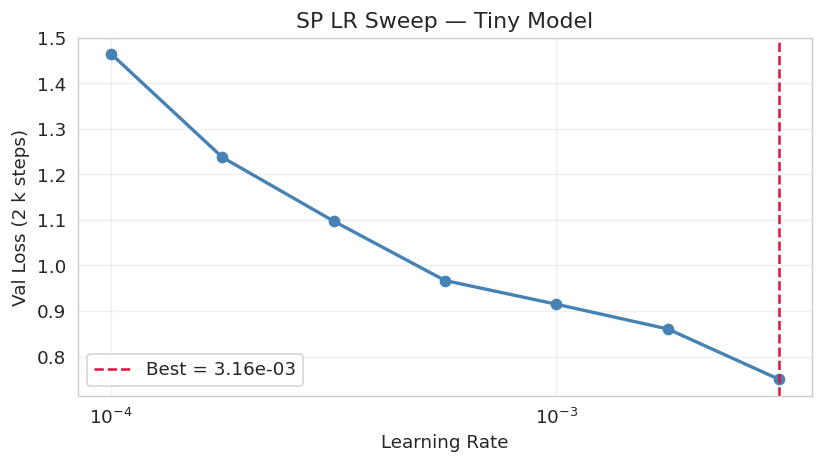

In [15]:
SWEEP_STEPS  = 2000
LR_GRID      = list(np.logspace(-4, -2.5, 7))

probe_cfg = ArchConfig(vocab_size=VOCAB_SIZE, block_size=SEQ_LEN, **SIZE_CONFIGS['tiny'])
sweep_sp: Dict[float, float] = {}

print('=== SP Learning-Rate Sweep (Tiny, 2k steps) ===')
for lr in LR_GRID:
    m   = SVGDecoder(probe_cfg).to(DEVICE)
    res = fit_model(m, lr=lr, max_steps=SWEEP_STEPS,
                    run_name=f'sp_sweep_{lr:.1e}', log_every=500, eval_every=500)
    sweep_sp[lr] = res['final_val_loss']
    del m
    if DEVICE.type == 'cuda': torch.cuda.empty_cache()

best_lr_sp = min(sweep_sp, key=sweep_sp.get)
print(f'\nBest SP LR: {best_lr_sp:.2e}  →  val loss {sweep_sp[best_lr_sp]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(list(sweep_sp.keys()), list(sweep_sp.values()), 'o-', color='steelblue', lw=2)
ax.axvline(best_lr_sp, color='crimson', ls='--', label=f'Best = {best_lr_sp:.2e}')
ax.set(xlabel='Learning Rate', ylabel='Val Loss (2 k steps)',
       title='SP LR Sweep — Tiny Model')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'lr_sweep_sp.png', dpi=130)
plt.show()

## 5 · Part 2 — SP Scaling Study

Train Tiny through XL at the fixed best LR for exactly 1 epoch.
If a `_final.pt` checkpoint already exists the cell loads it instead of re-training
(safe to re-run after interruption).

In [16]:
hf_pull_all()   # restore any completed checkpoints from HF Hub on reconnect

results_sp: Dict[str, dict] = {}
print(f'SP Scaling Study  (LR={best_lr_sp:.2e})')
print('─' * 55)

for sz_name, sz_kw in SIZE_CONFIGS.items():
    final_ckpt = CKPT_DIR / f'sp_{sz_name}_final.pt'

    if final_ckpt.exists():
        ckpt = torch.load(final_ckpt, map_location='cpu', weights_only=False)
        results_sp[sz_name] = ckpt['stats']
        print(f'  Loaded  sp_{sz_name:<6}  val={ckpt["stats"]["final_val_loss"]:.4f}')
    else:
        cfg = ArchConfig(vocab_size=VOCAB_SIZE, block_size=SEQ_LEN, **sz_kw)
        m   = SVGDecoder(cfg).to(DEVICE)
        print(f'  Training sp_{sz_name:<6}  ({m.param_count():,} params)')
        res = fit_model(m, lr=best_lr_sp, run_name=f'sp_{sz_name}',
                        log_every=200, eval_every=500, save_every=200)
        results_sp[sz_name] = res
        hf_push(CKPT_DIR / f'sp_{sz_name}_final.pt')
        del m
        if DEVICE.type == 'cuda': torch.cuda.empty_cache()

print('\nSP Results')
print(f'  {"Size":<8} {"Params":>12} {"Val Loss":>10} {"Time (s)":>10} {"Peak GPU MB":>13}')
print('  ' + '─' * 59)
for sz, r in results_sp.items():
    print(f'  {sz:<8} {r["n_params"]:>12,} {r["final_val_loss"]:>10.4f} '
          f'{r.get("elapsed_s", 0):>10.0f} {r.get("gpu_mb_peak", 0):>13.0f}')

with open(OUT_DIR / 'sp_results.json', 'w') as f:
    json.dump(
        {k: {kk: vv for kk, vv in v.items() if kk not in ('train_curve', 'val_curve')}
         for k, v in results_sp.items()},
        f, indent=2,
    )

SP Scaling Study  (LR=3.16e-03)
───────────────────────────────────────────────────────
  Training sp_tiny    (1,377,408 params)
[sp_tiny]      0/11044  loss=8.3517  lr=0.00e+00  16384 tok/s  0s
  ↳ val loss 8.3533
[sp_tiny]    200/11044  loss=1.6483  lr=3.16e-03  1212050 tok/s  3s
[sp_tiny]    400/11044  loss=1.1977  lr=3.16e-03  1374441 tok/s  5s
  ↳ val loss 1.2134
[sp_tiny]    600/11044  loss=1.0101  lr=3.15e-03  1353815 tok/s  7s
[sp_tiny]    800/11044  loss=1.1783  lr=3.14e-03  1391764 tok/s  9s
[sp_tiny]   1000/11044  loss=0.9633  lr=3.12e-03  1411429 tok/s  12s
  ↳ val loss 1.0122
[sp_tiny]   1200/11044  loss=0.9039  lr=3.10e-03  1393594 tok/s  14s
[sp_tiny]   1400/11044  loss=0.8213  lr=3.08e-03  1421483 tok/s  16s
  ↳ val loss 0.8889
[sp_tiny]   1600/11044  loss=1.0106  lr=3.05e-03  1410077 tok/s  19s
[sp_tiny]   1800/11044  loss=0.9178  lr=3.01e-03  1427444 tok/s  21s
[sp_tiny]   2000/11044  loss=0.7422  lr=2.97e-03  1440459 tok/s  23s
  ↳ val loss 0.8317
[sp_tiny]   2200/11

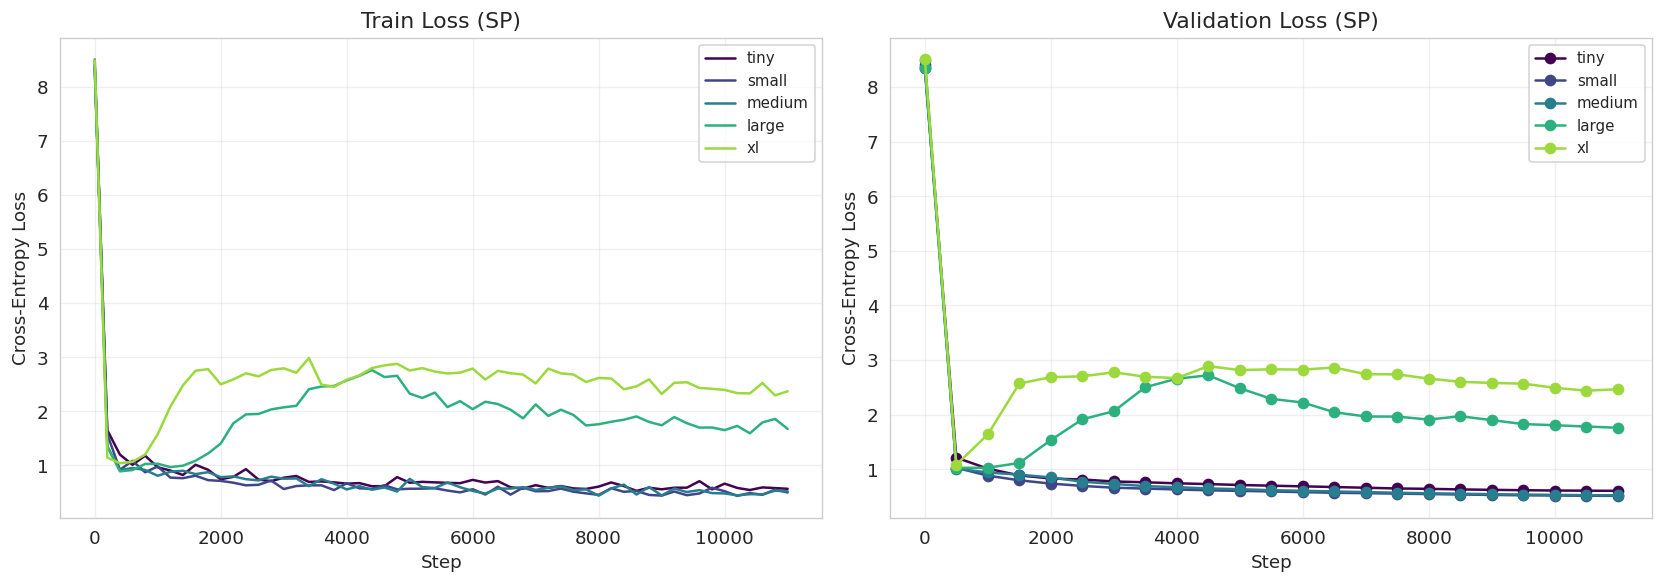

In [17]:
fig, (ax_tr, ax_va) = plt.subplots(1, 2, figsize=(14, 5))
palette = plt.cm.viridis(np.linspace(0, 0.85, len(results_sp)))

for (sz, res), col in zip(results_sp.items(), palette):
    tr_steps  = [s for s, _ in res['train_curve']]
    tr_losses = [l for _, l in res['train_curve']]
    ax_tr.plot(tr_steps, tr_losses, label=sz, color=col)

    va_steps  = [s for s, _ in res['val_curve']]
    va_losses = [l for _, l in res['val_curve']]
    ax_va.plot(va_steps, va_losses, 'o-', label=sz, color=col)

for ax, title in [(ax_tr, 'Train Loss (SP)'), (ax_va, 'Validation Loss (SP)')]:
    ax.set(xlabel='Step', ylabel='Cross-Entropy Loss', title=title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves_sp.png', dpi=130)
plt.show()

## 6 · Part 3 — µP Scaling Study

**Maximal Update Parameterisation (µP)** (Yang et al., 2022) makes the optimal learning
rate width-invariant: tune once on a tiny proxy and transfer to all larger widths without
retuning.

Implementation via the `mup` package:
1. Build a narrow *base* model at width 64.
2. Call `set_base_shapes(model, base)` — registers per-layer LR multipliers.
3. Replace standard `AdamW` with `MuAdamW`.
4. In attention: use `1/d_head` scaling instead of `1/√d_head`.
5. Replace output head with `MuReadout`.

In [18]:
try:
    from mup import MuReadout, set_base_shapes, MuAdamW
    HAS_MUP = True
    print('mup package found ✓')
except ImportError:
    HAS_MUP = False
    print('mup not found — µP section will be skipped.')


def build_mup_model(cfg: ArchConfig, base_width: int = 64) -> SVGDecoder:
    """Return an SVGDecoder with µP base shapes registered."""
    if not HAS_MUP:
        raise ImportError('pip install mup')
    ratio    = base_width / cfg.d_model
    base_cfg = ArchConfig(
        vocab_size = cfg.vocab_size,
        block_size = cfg.block_size,
        d_model    = base_width,
        n_layers   = cfg.n_layers,
        n_heads    = max(1, round(cfg.n_heads * ratio)),
        d_ff       = max(4, round(cfg.d_ff    * ratio)),
        dropout    = cfg.dropout,
        bias       = cfg.bias,
    )
    base  = SVGDecoder(base_cfg, mup_attn=True)
    model = SVGDecoder(cfg,      mup_attn=True)
    set_base_shapes(model, base, delta=None)
    del base
    return model

mup package found ✓


=== µP Learning-Rate Sweep (Tiny, 2k steps) ===
[mup_sweep_1.0e-04]      0/2000  loss=8.3161  lr=0.00e+00  16384 tok/s  0s
  ↳ val loss 8.3157
[mup_sweep_1.0e-04]    500/2000  loss=3.7885  lr=9.40e-05  756665 tok/s  11s
  ↳ val loss 3.8601
[mup_sweep_1.0e-04]   1000/2000  loss=2.1361  lr=6.28e-05  774003 tok/s  21s
  ↳ val loss 2.1671
[mup_sweep_1.0e-04]   1500/2000  loss=1.8683  lr=2.61e-05  779590 tok/s  32s
  ↳ val loss 1.8314
[mup_sweep_1.0e-04] Done  val=1.7241  42s  peak GPU 7592 MB
[mup_sweep_1.8e-04]      0/2000  loss=8.3695  lr=0.00e+00  16384 tok/s  0s
  ↳ val loss 8.3691
[mup_sweep_1.8e-04]    500/2000  loss=2.5649  lr=1.67e-04  768364 tok/s  11s
  ↳ val loss 2.4349
[mup_sweep_1.8e-04]   1000/2000  loss=1.5485  lr=1.12e-04  770498 tok/s  21s
  ↳ val loss 1.6596
[mup_sweep_1.8e-04]   1500/2000  loss=1.3965  lr=4.64e-05  775553 tok/s  32s
  ↳ val loss 1.4918
[mup_sweep_1.8e-04] Done  val=1.4126  42s  peak GPU 7592 MB
[mup_sweep_3.2e-04]      0/2000  loss=8.3483  lr=0.00e+00  1

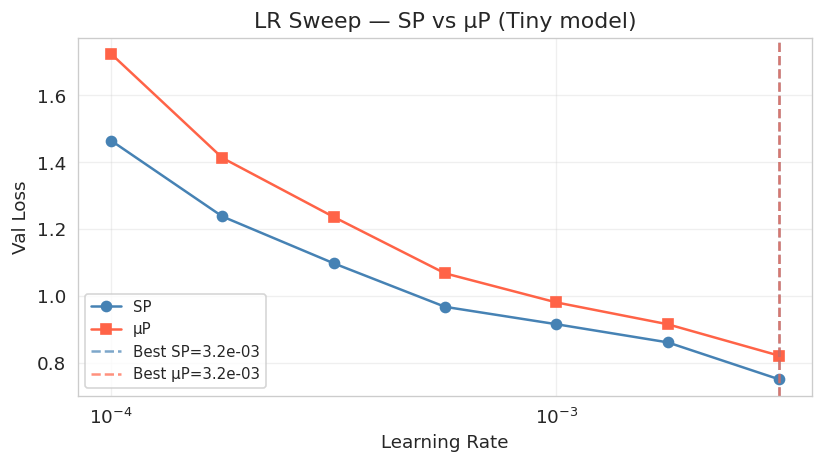

In [19]:
sweep_mup: Dict[float, float] = {}

if HAS_MUP:
    print('=== µP Learning-Rate Sweep (Tiny, 2k steps) ===')
    for lr in LR_GRID:
        m   = build_mup_model(probe_cfg).to(DEVICE)
        res = fit_model(m, lr=lr, max_steps=SWEEP_STEPS,
                        run_name=f'mup_sweep_{lr:.1e}', use_mup=True,
                        log_every=500, eval_every=500)
        sweep_mup[lr] = res['final_val_loss']
        del m
        if DEVICE.type == 'cuda': torch.cuda.empty_cache()

    best_lr_mup = min(sweep_mup, key=sweep_mup.get)
    print(f'\nBest µP LR: {best_lr_mup:.2e}  →  val loss {sweep_mup[best_lr_mup]:.4f}')

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogx(list(sweep_sp.keys()),  list(sweep_sp.values()),  'o-',
                color='steelblue', label='SP')
    ax.semilogx(list(sweep_mup.keys()), list(sweep_mup.values()), 's-',
                color='tomato',    label='µP')
    ax.axvline(best_lr_sp,  color='steelblue', ls='--', alpha=0.7,
               label=f'Best SP={best_lr_sp:.1e}')
    ax.axvline(best_lr_mup, color='tomato',    ls='--', alpha=0.7,
               label=f'Best µP={best_lr_mup:.1e}')
    ax.set(xlabel='Learning Rate', ylabel='Val Loss',
           title='LR Sweep — SP vs µP (Tiny model)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'lr_sweep_comparison.png', dpi=130)
    plt.show()
else:
    print('Skipping µP LR sweep (mup not installed).')
    best_lr_mup = best_lr_sp

In [20]:
results_mup: Dict[str, dict] = {}

if HAS_MUP:
    hf_pull_all()   # restore any completed checkpoints from HF Hub on reconnect

    print(f'µP Scaling Study  (LR={best_lr_mup:.2e})')
    print('─' * 55)

    for sz_name, sz_kw in SIZE_CONFIGS.items():
        final_ckpt = CKPT_DIR / f'mup_{sz_name}_final.pt'

        if final_ckpt.exists():
            ckpt = torch.load(final_ckpt, map_location='cpu', weights_only=False)
            results_mup[sz_name] = ckpt['stats']
            print(f'  Loaded  mup_{sz_name:<6}  val={ckpt["stats"]["final_val_loss"]:.4f}')
        else:
            cfg = ArchConfig(vocab_size=VOCAB_SIZE, block_size=SEQ_LEN, **sz_kw)
            m   = build_mup_model(cfg).to(DEVICE)
            print(f'  Training mup_{sz_name:<6}  ({m.param_count():,} params)')
            res = fit_model(m, lr=best_lr_mup, run_name=f'mup_{sz_name}',
                            use_mup=True, log_every=200, eval_every=500, save_every=200)
            results_mup[sz_name] = res
            hf_push(CKPT_DIR / f'mup_{sz_name}_final.pt')
            del m
            if DEVICE.type == 'cuda': torch.cuda.empty_cache()

    print('\nµP Results')
    print(f'  {"Size":<8} {"Params":>12} {"Val Loss":>10} {"Time (s)":>10}')
    print('  ' + '─' * 46)
    for sz, r in results_mup.items():
        print(f'  {sz:<8} {r["n_params"]:>12,} {r["final_val_loss"]:>10.4f} '
              f'{r.get("elapsed_s", 0):>10.0f}')

    with open(OUT_DIR / 'mup_results.json', 'w') as f:
        json.dump(
            {k: {kk: vv for kk, vv in v.items() if kk not in ('train_curve', 'val_curve')}
             for k, v in results_mup.items()},
            f, indent=2,
        )
else:
    print('mup not installed — µP results unavailable.')

µP Scaling Study  (LR=3.16e-03)
───────────────────────────────────────────────────────
  Training mup_tiny    (1,901,696 params)
[mup_tiny]      0/11044  loss=8.3432  lr=0.00e+00  16384 tok/s  0s
  ↳ val loss 8.3445
[mup_tiny]    200/11044  loss=1.8724  lr=3.16e-03  708159 tok/s  5s
[mup_tiny]    400/11044  loss=1.3571  lr=3.16e-03  768311 tok/s  9s
  ↳ val loss 1.2327
[mup_tiny]    600/11044  loss=1.0076  lr=3.15e-03  754002 tok/s  13s
[mup_tiny]    800/11044  loss=1.0511  lr=3.14e-03  770584 tok/s  17s
[mup_tiny]   1000/11044  loss=0.8741  lr=3.12e-03  778047 tok/s  21s
  ↳ val loss 0.9846
[mup_tiny]   1200/11044  loss=0.9773  lr=3.10e-03  765390 tok/s  26s
[mup_tiny]   1400/11044  loss=1.1240  lr=3.08e-03  773494 tok/s  30s
  ↳ val loss 0.9042
[mup_tiny]   1600/11044  loss=0.9552  lr=3.05e-03  767888 tok/s  34s
[mup_tiny]   1800/11044  loss=0.8275  lr=3.01e-03  774650 tok/s  38s
[mup_tiny]   2000/11044  loss=0.8000  lr=2.97e-03  780155 tok/s  42s
  ↳ val loss 0.8356
[mup_tiny]   22

## 7 · Part 3 — Power-Law Fitting and Extrapolation

Fit `L = a · N^{-α} + c` to both curves via non-linear least squares.
A 95% confidence interval on the extrapolation is derived by the delta method
applied to the covariance matrix returned by `scipy.optimize.curve_fit`.

The 10× extrapolation point (⭐) predicts validation loss for a model with
10× the parameters of the largest trained model (XL ~88 M → ~880 M).

[SP]  α=1.9982  a=6.7655  c=1.1444
  Extrapolation  N=8.85e+08  →  L=1.1444 ± 2.3676  (95% CI, dof=2)
[µP]  α=1.0120  a=144887.6180  c=0.4857
  Extrapolation  N=9.16e+08  →  L=0.4858 ± 0.0395  (95% CI, dof=2)


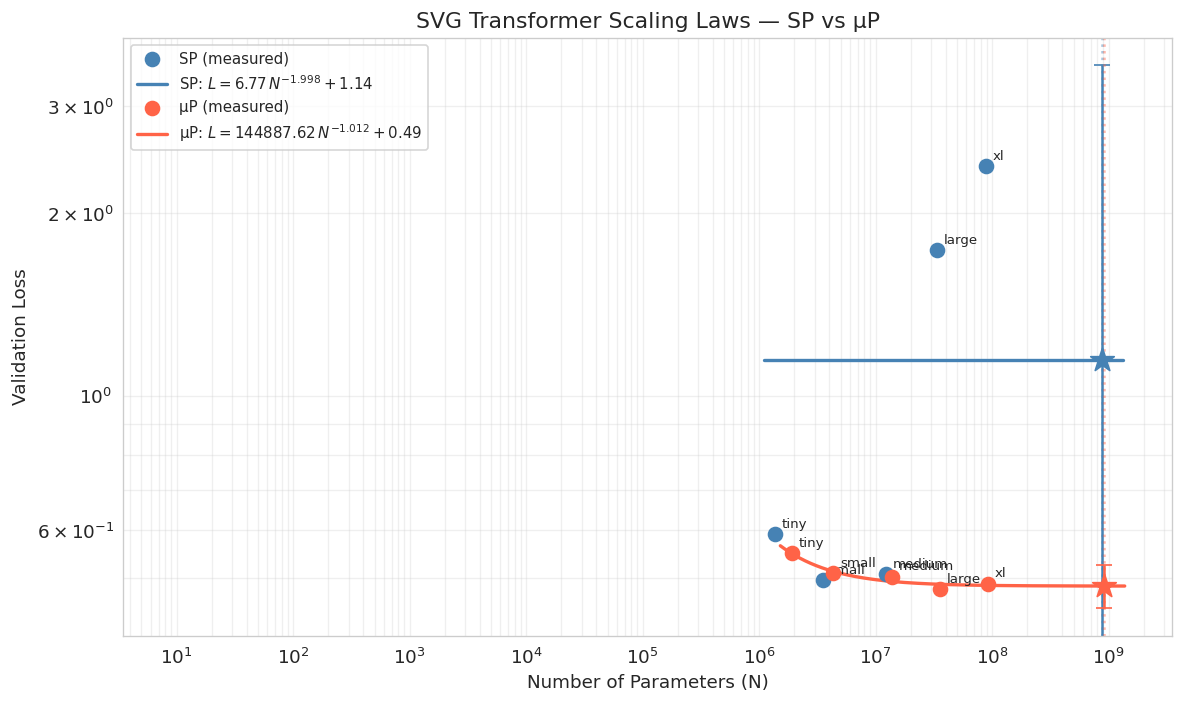

In [21]:
def power_law_fn(N, a, alpha, c):
    return a * np.power(N, -alpha) + c


def fit_scaling(results: dict, label: str, color: str, ax,
                extrap_factor: int = 10) -> dict:
    keys  = list(results.keys())
    N = np.array([results[k]['n_params']       for k in keys], dtype=float)
    L = np.array([results[k]['final_val_loss'] for k in keys], dtype=float)
    order = np.argsort(N)
    N, L, keys = N[order], L[order], [keys[i] for i in order]

    try:
        popt, pcov = curve_fit(
            power_law_fn, N, L,
            p0=[10.0, 0.1, 1.0],
            bounds=([0, 0, 0], [np.inf, 2, np.inf]),
            maxfev=10_000,
        )
    except RuntimeError:
        popt, pcov = np.array([1.0, 0.1, 1.0]), np.eye(3)

    a, alpha, c = popt
    N_range = np.logspace(np.log10(N.min() * 0.8),
                          np.log10(N.max() * extrap_factor * 1.5), 500)
    L_range = power_law_fn(N_range, *popt)

    ax.scatter(N, L, s=70, color=color, zorder=5, label=f'{label} (measured)')
    ax.loglog(N_range, L_range, '-', color=color, lw=2,
              label=rf'{label}: $L={a:.2f}\,N^{{-{alpha:.3f}}}+{c:.2f}$')
    for n, l, k in zip(N, L, keys):
        ax.annotate(k, (n, l), textcoords='offset points', xytext=(4, 4), fontsize=8)

    # 10× extrapolation with 95% CI (delta method)
    N_ext = float(N.max() * extrap_factor)
    L_ext = power_law_fn(N_ext, *popt)
    jac   = np.array([N_ext**(-alpha),
                      -a * np.log(N_ext) * N_ext**(-alpha),
                      1.0])
    se    = np.sqrt(max(0.0, jac @ pcov @ jac))
    dof   = max(1, len(N) - 3)
    ci95  = float(tdist.ppf(0.975, dof) * se)

    ax.scatter([N_ext], [L_ext], marker='*', s=220, color=color, zorder=6)
    ax.errorbar([N_ext], [L_ext], yerr=[[ci95], [ci95]], fmt='none',
                color=color, capsize=5)
    ax.axvline(N_ext, ls=':', color=color, alpha=0.45)

    print(f'[{label}]  α={alpha:.4f}  a={a:.4f}  c={c:.4f}')
    print(f'  Extrapolation  N={N_ext:.2e}  →  L={L_ext:.4f} ± {ci95:.4f}  (95% CI, dof={dof})')
    return dict(alpha=alpha, a=a, c=c, N_ext=N_ext, L_ext=float(L_ext), ci95=ci95)


fig, ax = plt.subplots(figsize=(10, 6))
fit_sp  = fit_scaling(results_sp,  'SP',  'steelblue', ax)
fit_mup = {}
if results_mup:
    fit_mup = fit_scaling(results_mup, 'µP', 'tomato', ax)

ax.set(xlabel='Number of Parameters (N)',
       ylabel='Validation Loss',
       title='SVG Transformer Scaling Laws — SP vs µP')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'scaling_curves.png', dpi=150)
plt.show()

## 8 · Part 4 — Best Model Extended Training

Load the XL checkpoint from Part 2 and continue training for additional epoch(s)
at 30% of the base LR (standard fine-tuning warm-down strategy).

In [22]:
hf_pull_all()   # restore sp_xl_best.pt and any other completed checkpoints

FINETUNE_EPOCHS = 1   # increase if GPU budget allows

xl_cfg     = ArchConfig(vocab_size=VOCAB_SIZE, block_size=SEQ_LEN, **SIZE_CONFIGS['xl'])
best_model = SVGDecoder(xl_cfg).to(DEVICE)

xl_ckpt = CKPT_DIR / 'sp_xl_best.pt'
if xl_ckpt.exists():
    ckpt = torch.load(xl_ckpt, map_location=DEVICE, weights_only=False)
    best_model.load_state_dict(ckpt['model'])
    print(f'Loaded XL checkpoint from {xl_ckpt}')
else:
    print('No XL checkpoint found — starting from random init.')

print(f'Extended training: {FINETUNE_EPOCHS} epoch(s)  LR={best_lr_sp * 0.3:.2e}')
for ep in range(FINETUNE_EPOCHS):
    res = fit_model(best_model, lr=best_lr_sp * 0.3,
                    run_name=f'best_ep{ep}', log_every=200, eval_every=500)
    print(f'  Epoch {ep + 1}: val loss = {res["final_val_loss"]:.4f}')
    hf_push(CKPT_DIR / f'best_ep{ep}_final.pt')

best_model.eval()
print('Best model ready for generation.')

Loaded XL checkpoint from /content/checkpoints/sp_xl_best.pt
Extended training: 1 epoch(s)  LR=9.49e-04
[best_ep0]      0/11044  loss=1.1237  lr=0.00e+00  16384 tok/s  0s
  ↳ val loss 1.0838
[best_ep0]    200/11044  loss=0.8815  lr=9.49e-04  158216 tok/s  21s
[best_ep0]    400/11044  loss=0.8696  lr=9.48e-04  184962 tok/s  36s
  ↳ val loss 0.9823
[best_ep0]    600/11044  loss=0.9525  lr=9.46e-04  179339 tok/s  55s
[best_ep0]    800/11044  loss=0.9644  lr=9.42e-04  188476 tok/s  70s
[best_ep0]   1000/11044  loss=0.9264  lr=9.37e-04  194356 tok/s  84s
  ↳ val loss 0.9769
[best_ep0]   1200/11044  loss=0.9504  lr=9.31e-04  189472 tok/s  104s
[best_ep0]   1400/11044  loss=0.9094  lr=9.23e-04  193576 tok/s  119s
  ↳ val loss 0.9852
[best_ep0]   1600/11044  loss=0.9397  lr=9.14e-04  192710 tok/s  136s
[best_ep0]   1800/11044  loss=0.8945  lr=9.04e-04  195610 tok/s  151s
[best_ep0]   2000/11044  loss=1.0022  lr=8.92e-04  197986 tok/s  166s
  ↳ val loss 1.0164
[best_ep0]   2200/11044  loss=0.87

In [23]:
def detokenize(ids: List[int]) -> str:
    ids = [i for i in ids if i not in (BOS_ID, EOS_ID)]
    return tok.decode(ids)


def generate(
    model: SVGDecoder,
    prefix: str = '<svg',
    n: int = 5,
    max_new: int = 400,
    temperature: float = 1.0,
    top_k: int = 50,
    top_p: Optional[float] = None,
) -> List[str]:
    prefix_ids = tok.encode(prefix).ids
    prompt     = torch.tensor([[BOS_ID] + prefix_ids], dtype=torch.long, device=DEVICE)
    outputs    = []
    for _ in range(n):
        out     = model.sample_tokens(
            prompt.clone(), max_new=max_new,
            temperature=temperature, top_k=top_k,
            top_p=top_p, eos_id=EOS_ID,
        )
        gen_ids = out[0, len(prefix_ids) + 1:].tolist()
        outputs.append(prefix + detokenize(gen_ids))
    return outputs


print('=== Unconditional samples  (T=0.8, top_k=50) ===')
uncond_t08 = generate(best_model, n=10, temperature=0.8)
for i, svg in enumerate(uncond_t08[:3], 1):
    print(f'\n--- Sample {i} ---')
    print(svg[:300] + ('…' if len(svg) > 300 else ''))

=== Unconditional samples  (T=0.8, top_k=50) ===

--- Sample 1 ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M15.0 3.6 L16.0 3.0 L15.7 3.0 L21.3 7.0 L20.6 7.0 L15.3 7.0 L11.1 8.0 L7.9 3.2 L15.9 3.9"></path> <path fi…

--- Sample 2 ---
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M12.4 7.6 L12.4 10.8 C13.4 10.8 12.6 11.5 12.6 13.5 L12.2 14.8 C13.5 14.4 13.9 14.2 13.8 14.2 13.6 14.1 L13.9 13.1 C…

--- Sample 3 ---
<svg xmlnssvg xmlns="http://www.w3.org/svg" viewBox="0.0 0.0 24.0 24.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M5.0 3.4 L11.0 4.4 C13.4 5.1 14.4 5.1 14.7 7.3 C13.3 7.0 13.1 7.1 13.0 7.2 C13.9 7.0 7.4 7.3 9.

In [24]:
# Prefix-conditioned generation — test structural coherence
PARTIAL_SVGS = [
    '<svg viewBox="0 0 100 100"><circle cx="50" cy="50" r="40"/><circle cx="35" cy="40" r="5"',
    '<svg viewBox="0 0 100 100"><path d="M10 50 L50 10 L90 50',
    '<svg viewBox="0 0 100 100"><g><rect x="10" y="10" width="30" height="30"',
    '<svg viewBox="0 0 24 24"><path d="M12 2C6.48 2 2 6.48 2 12',
    '<svg viewBox="0 0 100 100"><polygon points="50,5 61,35 95,35',
]

prefix_outs: Dict[str, dict] = {}
for idx, prefix in enumerate(PARTIAL_SVGS, 1):
    print(f'\nPrefix {idx}: {prefix[:70]}…')
    completions = generate(best_model, prefix=prefix, n=2, temperature=0.8)
    prefix_outs[f'prefix_{idx}'] = {'prefix': prefix, 'completions': completions}
    for j, c in enumerate(completions, 1):
        print(f'  Completion {j}: {c[len(prefix):len(prefix)+150]}')


Prefix 1: <svg viewBox="0 0 100 100"><circle cx="50" cy="50" r="40"/><circle cx=…
  Completion 1:  xmlns="http://www.w3.org/2000/svg"><defs>.4.0 0.6fill:="200px"><line id="a="M32.1" stroke="a="16.3 34.5="c14" cyg class="a" x2line class="a.5="28.5" 
  Completion 2:  fill="none" xmlns="black" xmlns="http://www.w3.org/2000/svg1999 stroke:xlink"> <path d="black" stroke-width="1.0" d="M14C21.0 14.5 14.8 14.3 14.3 21.

Prefix 2: <svg viewBox="0 0 100 100"><path d="M10 50 L50 10 L90 50…
  Completion 1: ,1,11 C6,0.3,1.2,19.2-20.3,25.25,16,0,21.6,24,22.6,11.5,20.7,8.8,18.4.7.9,16.4,10.5,7-19.5,0.6,2020.7,16.8,12.7,21.0,20.6C30.5,24.0,19.2,5,6,29.5,14.3
  Completion 2: ,14.w3.1 C48.6 60.6,22.5 51.5 26.9 L50.2 26.7 C31.4 25.1 51.4 30.0 C54.2 29.1 49.2 29.0 51.3 30.0 49.0 C26.4 52.2 30.7 51.7 30.9 49.3 29.0 51.6 30.8 C

Prefix 3: <svg viewBox="0 0 100 100"><g><rect x="10" y="10" width="30" height="3…
  Completion 1:  xmlns="2C10" y1="2.4="29.2" y="8="4"/> </line" x1" x2="17" fill="#="white"/> <pa

In [25]:
print('=== Temperature ablation (T ∈ {0.5, 0.8, 1.0}) ===')
temp_outs: Dict[float, List[str]] = {}

for temp in [0.5, 0.8, 1.0]:
    s = generate(best_model, n=10, temperature=temp)
    temp_outs[temp] = s
    print(f'\nT={temp}: {s[0][:200]}')

=== Temperature ablation (T ∈ {0.5, 0.8, 1.0}) ===

T=0.5: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M11.7 

T=0.8: <svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M8.3 1

T=1.0: <svg xmlnssvg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="M11.5 3.9 L9.


## 9 · Part 4 — Evaluation Metrics

* **Perplexity** — cross-entropy on the held-out test set, exponentiated.
* **XML validity** — `lxml.etree.fromstring` without error.
* **Render rate** — `cairosvg.svg2png` without error.
* **Structural validity** — has `<svg` root and a closing tag.

In [26]:
try:
    import cairosvg
    HAS_CAIRO = True
except ImportError:
    HAS_CAIRO = False


def xml_valid(text: str) -> bool:
    if not HAS_LXML: return True
    try:    etree.fromstring(text.encode()); return True
    except: return False


def svg_renders(text: str) -> bool:
    if not HAS_CAIRO: return True
    try:    cairosvg.svg2png(bytestring=text.encode()); return True
    except: return False


def struct_valid(text: str) -> bool:
    t = text.strip()
    return '<svg' in t and ('</svg>' in t or t.rstrip().endswith('>'))


def score_samples(samples: List[str]) -> dict:
    n = len(samples)
    return {
        'n'                  : n,
        'xml_validity'       : sum(xml_valid(s)   for s in samples) / n,
        'render_rate'        : sum(svg_renders(s) for s in samples) / n,
        'structural_validity': sum(struct_valid(s) for s in samples) / n,
    }


# Perplexity on test set
test_ds     = PackedSVGDataset(str(DATA_DIR / 'test.bin'), SEQ_LEN)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

@torch.no_grad()
def compute_perplexity(model: SVGDecoder, loader, n_iters: int = 100) -> float:
    model.eval()
    total_loss = total_tok = 0
    for i, (x, y) in enumerate(loader):
        if i >= n_iters: break
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.bfloat16, enabled=USE_AMP):
            _, loss = model(x, y)
        total_loss += loss.item() * y.numel()
        total_tok  += y.numel()
    return math.exp(total_loss / max(1, total_tok))


ppl = compute_perplexity(best_model, test_loader)
print(f'Test perplexity: {ppl:.2f}')

all_gens = [s for sl in temp_outs.values() for s in sl]
agg = score_samples(all_gens)
print('\n=== Generation Quality (all temperatures) ===')
for k, v in agg.items():
    print(f'  {k}: {v:.3f}' if isinstance(v, float) else f'  {k}: {v}')

print('\nPer-temperature breakdown:')
for temp, sl in temp_outs.items():
    m = score_samples(sl)
    print(f'  T={temp}: xml={m["xml_validity"]:.0%}  '
          f'render={m["render_rate"]:.0%}  '
          f'struct={m["structural_validity"]:.0%}')

Test perplexity: 2.62

=== Generation Quality (all temperatures) ===
  n: 30
  xml_validity: 0.067
  render_rate: 0.033
  structural_validity: 0.233

Per-temperature breakdown:
  T=0.5: xml=10%  render=0%  struct=10%
  T=0.8: xml=10%  render=10%  struct=30%
  T=1.0: xml=0%  render=0%  struct=30%


## 10 · Save All Results

In [27]:
samples_dir = OUT_DIR / 'samples'
samples_dir.mkdir(exist_ok=True)

for temp, svglist in temp_outs.items():
    for i, svg in enumerate(svglist):
        (samples_dir / f'uncond_T{temp}_{i:02d}.svg').write_text(svg, encoding='utf-8')

for key, data in prefix_outs.items():
    for i, svg in enumerate(data['completions']):
        (samples_dir / f'{key}_{i:02d}.svg').write_text(svg, encoding='utf-8')

summary = {
    'vocab_size'        : VOCAB_SIZE,
    'seq_len'           : SEQ_LEN,
    'best_lr_sp'        : best_lr_sp,
    'best_lr_mup'       : best_lr_mup if HAS_MUP else None,
    'test_perplexity'   : ppl,
    'generation_metrics': agg,
    'sp_scaling'        : {k: {'n_params': v['n_params'],
                               'val_loss': v['final_val_loss']}
                           for k, v in results_sp.items()},
    'mup_scaling'       : {k: {'n_params': v['n_params'],
                               'val_loss': v['final_val_loss']}
                           for k, v in results_mup.items()} if results_mup else {},
    'power_law_sp'      : fit_sp,
    'power_law_mup'     : fit_mup,
}
with open(OUT_DIR / 'final_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f'All results saved to {OUT_DIR}/')
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(OUT_DIR)}')

All results saved to /content/results/
  final_summary.json
  length_dist.png
  lr_sweep_comparison.png
  lr_sweep_sp.png
  mup_results.json
  samples/prefix_1_00.svg
  samples/prefix_1_01.svg
  samples/prefix_2_00.svg
  samples/prefix_2_01.svg
  samples/prefix_3_00.svg
  samples/prefix_3_01.svg
  samples/prefix_4_00.svg
  samples/prefix_4_01.svg
  samples/prefix_5_00.svg
  samples/prefix_5_01.svg
  samples/uncond_T0.5_00.svg
  samples/uncond_T0.5_01.svg
  samples/uncond_T0.5_02.svg
  samples/uncond_T0.5_03.svg
  samples/uncond_T0.5_04.svg
  samples/uncond_T0.5_05.svg
  samples/uncond_T0.5_06.svg
  samples/uncond_T0.5_07.svg
  samples/uncond_T0.5_08.svg
  samples/uncond_T0.5_09.svg
  samples/uncond_T0.8_00.svg
  samples/uncond_T0.8_01.svg
  samples/uncond_T0.8_02.svg
  samples/uncond_T0.8_03.svg
  samples/uncond_T0.8_04.svg
  samples/uncond_T0.8_05.svg
  samples/uncond_T0.8_06.svg
  samples/uncond_T0.8_07.svg
  samples/uncond_T0.8_08.svg
  samples/uncond_T0.8_09.svg
  samples/uncond_T1

## 11 · Download Results (Colab)

Zip the entire `results/` directory and download to your local machine.

In [28]:
import shutil, zipfile

ZIP_PATH = Path('/content/svg_scaling_results.zip')

# Create zip from an explicit absolute path so location is unambiguous
shutil.make_archive(str(ZIP_PATH.with_suffix('')), 'zip', str(OUT_DIR))

# Verify the zip is valid before downloading
if zipfile.is_zipfile(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH) as zf:
        names = zf.namelist()
    print(f'Zip OK — {len(names)} files  ({ZIP_PATH.stat().st_size / 1e6:.1f} MB)')
    print('\n'.join(f'  {n}' for n in names[:20]))
    if len(names) > 20:
        print(f'  … and {len(names) - 20} more')
else:
    print('ERROR: zip file is invalid — check that the results cells ran without errors.')

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
    print('Download started.')
except ImportError:
    print(f'Not in Colab — find the zip at {ZIP_PATH}')

Zip OK — 51 files  (0.4 MB)
  samples/
  length_dist.png
  training_curves_sp.png
  scaling_curves.png
  sp_results.json
  final_summary.json
  svg_examples.png
  lr_sweep_comparison.png
  mup_results.json
  lr_sweep_sp.png
  token_length_dist.png
  samples/uncond_T0.5_03.svg
  samples/uncond_T0.8_02.svg
  samples/prefix_2_01.svg
  samples/uncond_T0.5_07.svg
  samples/uncond_T1.0_09.svg
  samples/prefix_4_00.svg
  samples/uncond_T0.8_01.svg
  samples/uncond_T0.8_05.svg
  samples/uncond_T0.5_09.svg
  … and 31 more


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
